
# RESULTS

In this file we evaluate the out-of-sample performance of the early warning model. The analysis is structured in four parts:

1. **Feature group comparison** : we compare all combinations of feature blocks to understand the individual and joint contribution of each group to predictive performance.
2. **Final model selection** : based on the previous comparison, we define the final feature set and train the model with the selected configuration.
3. **Model evaluation** : we assess the final model through metrics (global, protracted, and hard onset), SHAP values, feature importance, and country-level examples.
4. **Robustness checks** : we evaluate performance across feature blocks separately, compare against XGBoost, and analyse regional heterogeneity.


### 0. Imports and Data Loading

In [38]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix
#import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from panelsplit.cross_validation import PanelSplit
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
import joblib

HYPERPARAMETER_TUNING = False  # Set to True if you want to perform hyperparameter tuning

In [39]:
# Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"
experiments_map["Optimal"] = "optimal"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 72


### 1. Feature group comparison

Here we are checking the performance of each combination.

In [46]:
def evaluate_experiments(plots_filter, df_master, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates ML experiments, plots ROC and PR curves,
    calculates metrics, and displays individual legends for each plot.
    """
    comparison_results = []
    
    # Prepare the graphics
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            continue
            
        print(f"Processing: {name}...")
        
        # Load predictions
        df_preds = pd.read_csv(pred_file)

        if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
            df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
        
        if 'month' in df_preds.columns:
            df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')

        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # Optimize threshold based on F1 score if not using 0.5
        if threshold_05:
            current_threshold = 0.5
        else:
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]

        df_preds['y_pred'] = (all_y_prob >= current_threshold).astype(int)

        # Global metrics
        f1 = f1_score(all_y_true, df_preds['y_pred'])
        prec = precision_score(all_y_true, df_preds['y_pred'], zero_division=0)
        rec = recall_score(all_y_true, df_preds['y_pred'])
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0

        # Subgroup metrics initialization 
        pro_prec, pro_rec, pro_f1, pro_roc_auc = np.nan, np.nan, np.nan, np.nan
        hard_prec, hard_rec, hard_f1, hard_roc_auc = np.nan, np.nan, np.nan, np.nan
        
        if 'is_protracted' not in df_preds.columns:
            if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
                df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

        if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
            # Protracted crises calculations
            pro_mask = df_preds['is_protracted'] == 1
            if pro_mask.sum() > 0:
                y_t_pro = df_preds.loc[pro_mask, 'y_true']
                y_p_pro = df_preds.loc[pro_mask, 'y_prob']
                y_pred_pro = df_preds.loc[pro_mask, 'y_pred']
                
                pro_prec = precision_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_rec = recall_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_f1 = f1_score(y_t_pro, y_pred_pro, zero_division=0)
                if len(np.unique(y_t_pro)) > 1:
                    pro_roc_auc = roc_auc_score(y_t_pro, y_p_pro)

            # Hard onset crises calculations
            hard_mask = df_preds['is_protracted'] == 0
            if hard_mask.sum() > 0:
                y_t_hard = df_preds.loc[hard_mask, 'y_true']
                y_p_hard = df_preds.loc[hard_mask, 'y_prob']
                y_pred_hard = df_preds.loc[hard_mask, 'y_pred']
                
                hard_prec = precision_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_rec = recall_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_f1 = f1_score(y_t_hard, y_pred_hard, zero_division=0)
                if len(np.unique(y_t_hard)) > 1:
                    hard_roc_auc = roc_auc_score(y_t_hard, y_p_hard)

        # Plotting ROC and PR curves
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})', drawstyle='steps-post')

        # Save results for comparison
        comparison_results.append({
            'Experiment': name,
            'Thr': round(current_threshold, 3),
            'Glob F1': round(f1, 3),
            'Glob P': round(prec, 3),
            'Glob R': round(rec, 3),
            'Glob AUC': round(roc_auc, 3),
            'Pro F1': round(pro_f1, 3) if pd.notna(pro_f1) else '-',
            'Pro P': round(pro_prec, 3) if pd.notna(pro_prec) else '-',
            'Pro R': round(pro_rec, 3) if pd.notna(pro_rec) else '-',
            'Pro AUC': round(pro_roc_auc, 3) if pd.notna(pro_roc_auc) else '-',
            'Hard F1': round(hard_f1, 3) if pd.notna(hard_f1) else '-',
            'Hard P': round(hard_prec, 3) if pd.notna(hard_prec) else '-',
            'Hard R': round(hard_rec, 3) if pd.notna(hard_rec) else '-',
            'Hard AUC': round(hard_roc_auc, 3) if pd.notna(hard_roc_auc) else '-',
            'Feats': num_features
        })

    # ROC formatting 
    ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc.set_ylabel('True Positive Rate', fontsize=11)
    ax_roc.grid(alpha=0.3)
    if ax_roc.has_data(): 
        ax_roc.legend(loc='lower right', fontsize=9)

    # PR formatting 
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall', fontsize=11)
    ax_pr.set_ylabel('Precision', fontsize=11)
    ax_pr.grid(alpha=0.3)
    if ax_pr.has_data(): 
        ax_pr.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

    # Print final ranking of experiments based on Global F1 score
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='Glob F1', ascending=False)
        print("\n" + "#"*160)
        print("FINAL RANKING (SORTED BY GLOBAL F1)".center(160))
        print("#"*160)
        print(df_results.to_string(index=False))
    else:
        print("\nNo experiments were successfully loaded.")

All the available models that we have, and that we can check their performance are:

In [11]:
models = list(experiments_map.keys())
print(models)

['Signals (CERF)', 'INFORM', 'INFORM + Signals (CERF)', 'Risk Alerts', 'Risk Alerts + Signals (CERF)', 'Risk Alerts + INFORM', 'Risk Alerts + INFORM + Signals (CERF)', 'Risk Alerts BEST', 'Risk Alerts BEST + Signals (CERF)', 'Risk Alerts BEST + INFORM', 'Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Signals (CERF)', 'Derived Humanitarian Impact + INFORM', 'Derived Humanitarian Impact + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts', 'Derived Humanitarian Impact + Risk Alerts + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts + INFORM', 'Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST', 'Derived Humanitarian Impact + Risk Alerts BEST + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact BEST', 'Der

Plotting the comparison of all the possible combinations:

Processing: Signals (CERF)...
Processing: INFORM...
Processing: INFORM + Signals (CERF)...
Processing: Risk Alerts...
Processing: Risk Alerts + Signals (CERF)...
Processing: Risk Alerts + INFORM...
Processing: Risk Alerts + INFORM + Signals (CERF)...
Processing: Risk Alerts BEST...
Processing: Risk Alerts BEST + Signals (CERF)...
Processing: Risk Alerts BEST + INFORM...
Processing: Risk Alerts BEST + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact...
Processing: Derived Humanitarian Impact + Signals (CERF)...
Processing: Derived Humanitarian Impact + INFORM...
Processing: Derived Humanitarian Impact + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts...
Processing: Derived Humanitarian Impact + Risk Alerts + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts BEST...
Pro

/var/folders/f0/99976rv943qfw3wg20pdpchh0000gn/T/ipykernel_24428/610742395.py:141: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


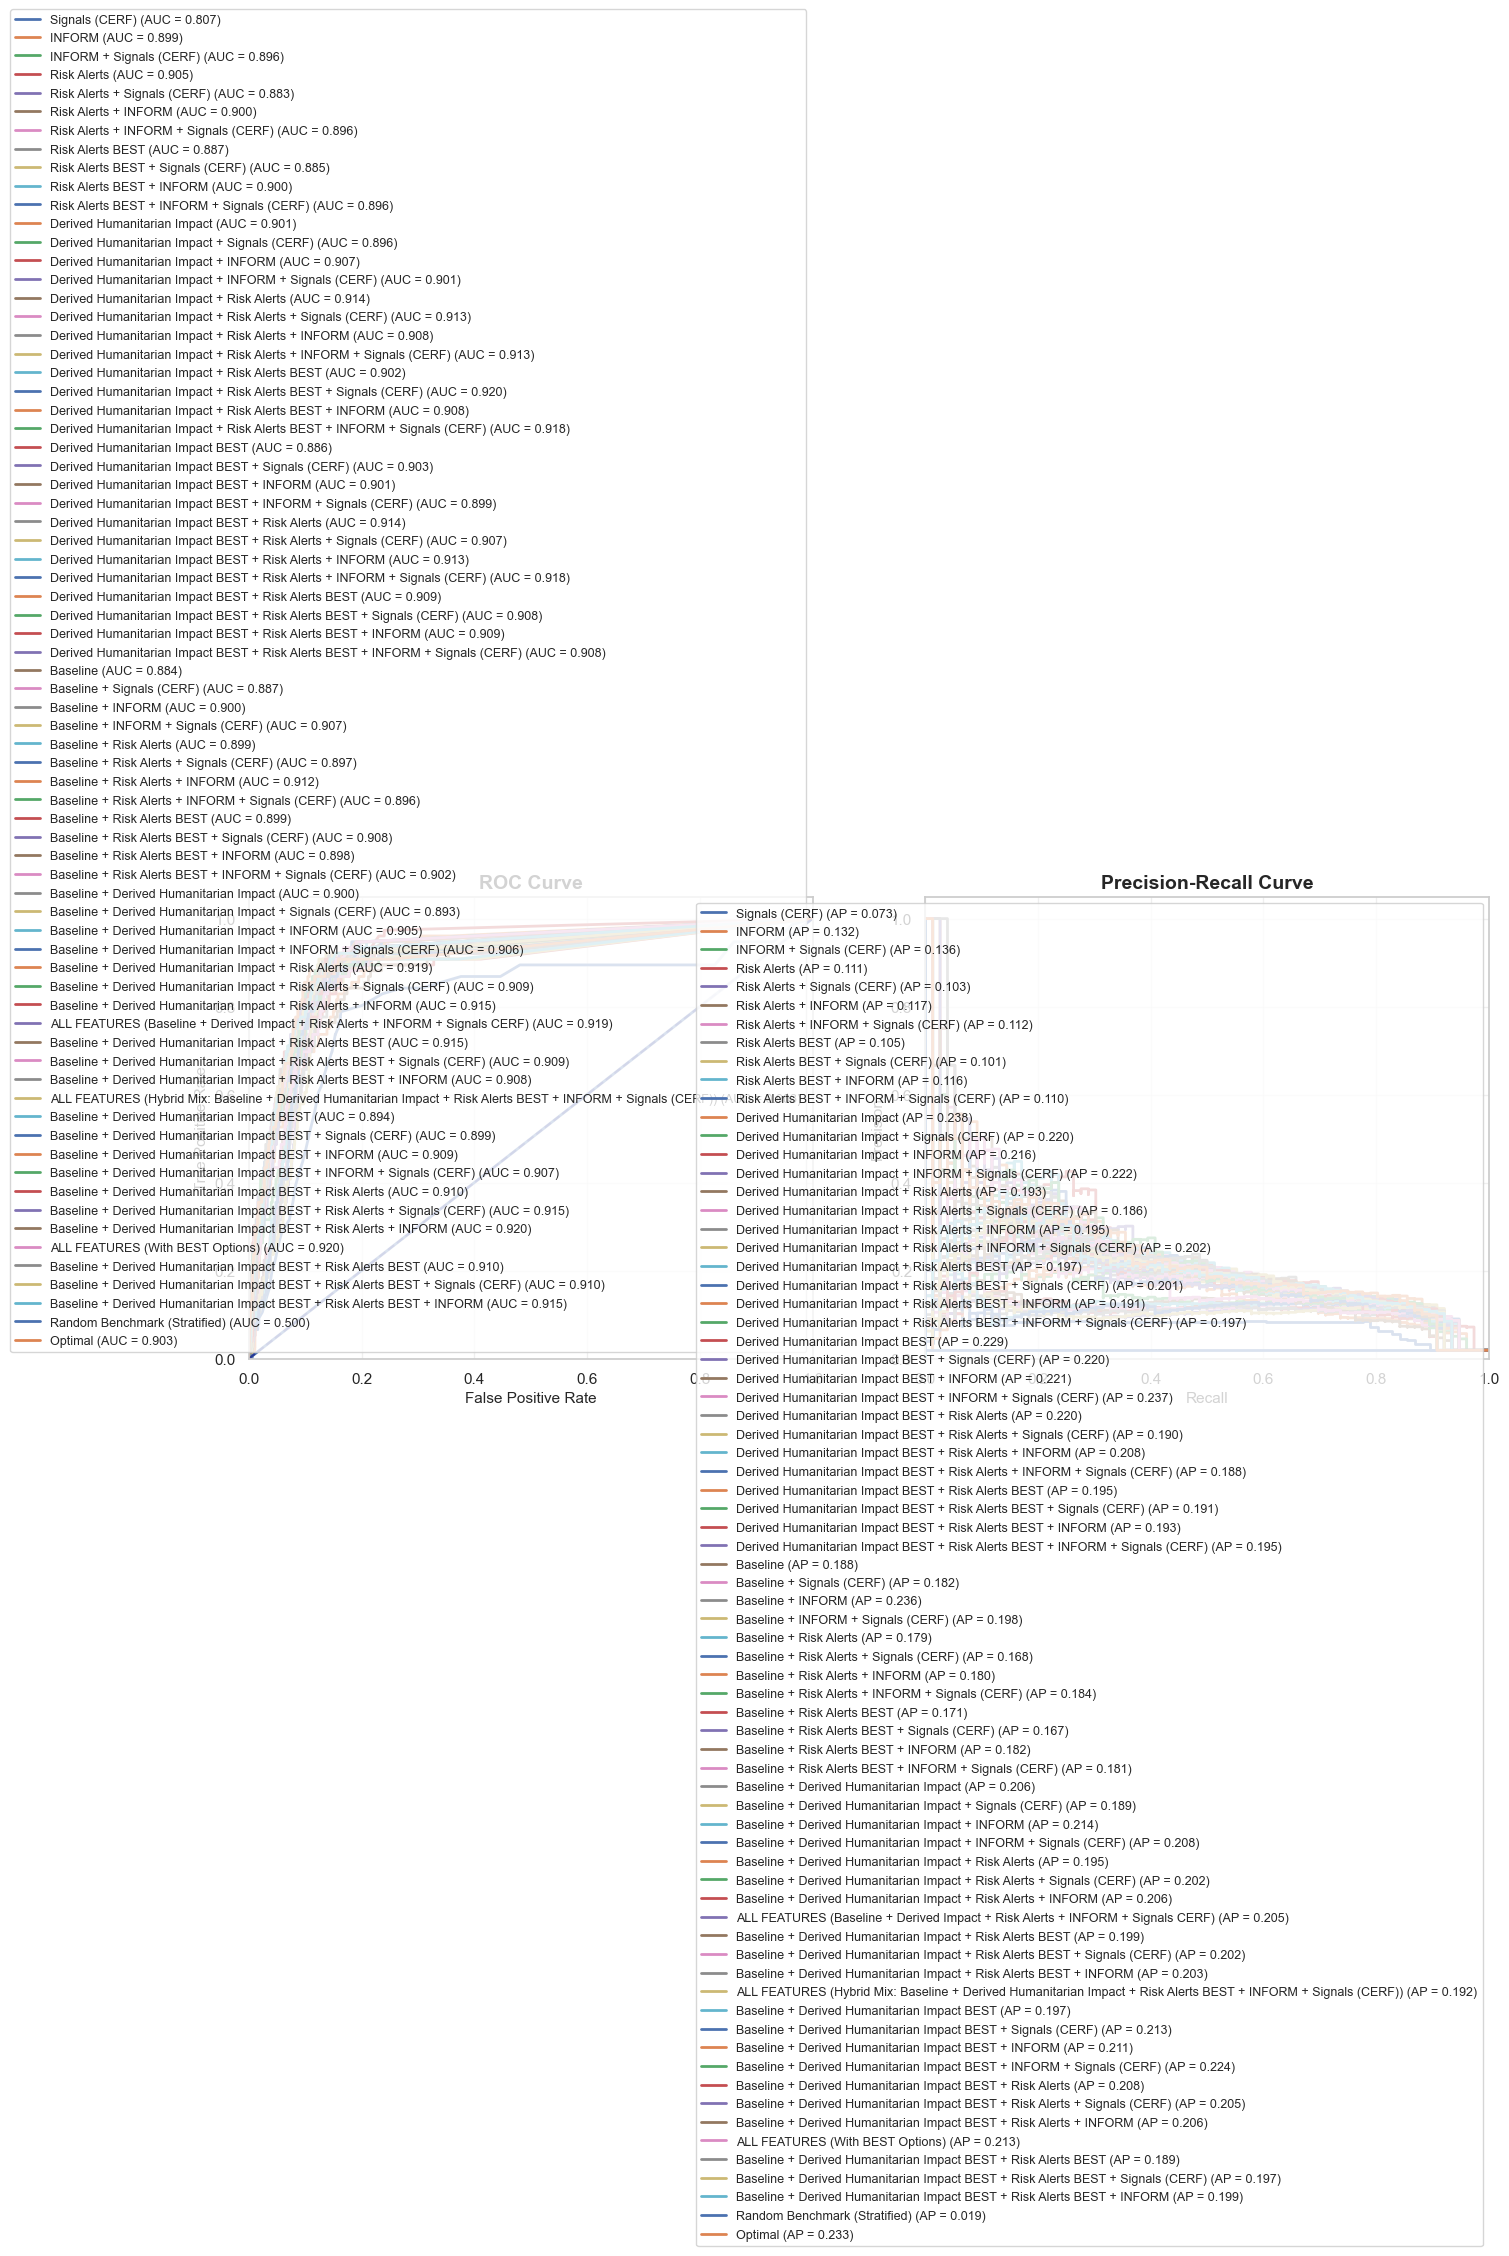


################################################################################################################################################################
                                                              FINAL RANKING (SORTED BY GLOBAL F1)                                                               
################################################################################################################################################################
                                                                                                    Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                                                                          Derived Humanitarian Impact + INFORM 0.791    0.338   0.383   0.303     0.907   0.355  0.355  0.355    0.671    0.324   0.414   0.267     0.903     35
                                                             Deriv

In [41]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

if 'iso3' not in df_original.columns:
    df_original = df_original.reset_index()
if 'month' in df_original.columns:
    df_original['month'] = pd.to_datetime(df_original['month'], errors='coerce')


evaluate_experiments(
    plots_filter=models, 
    df_master=df_original,
    threshold_05=False, 
    experiments_map=experiments_map
)

### 2. Final Model Selection (Final features group + hyperparameter tunning)

We have decided that our final model is the one containing the following features. The thing is that we have seen that INFORM, Derived Humanitarian Impact, and Cerf Signals are super usefull (the first two models have combonations of them). Also we see that the one with Derived Humanitarian Impact + INFORM has more precision, and the one with Derived Humanitarian Impact BEST + Signals (CERF) have more recall, so we think that joining them has to be useful. Also, regarding the risk variables, we see that including risk variables in general increases the recall, which is our main target, so even though we are not ading all the blok because it causes curse of dimensionality, we think that adding the main two variables is going to help the model increase the recall.

In [13]:
best_features_derived_humanitarian_impact =  ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals =  ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']

FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

Evaluate this final model, and retrained on the complete dataset.

In [14]:
RESULTS_FOLDER = "results"
FILE_PREFIX = "rf_baseline"

MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

os.makedirs(RESULTS_FOLDER, exist_ok=True)

# DATA PREPARATION FOR CROSS-VALIDATION
df_cv_prep = df_original.copy()

# Hide the latest 2 months per country to handle target reporting lag
last_2_months_mask = df_cv_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_cv_prep[TARGET_COL] = df_cv_prep[TARGET_COL].astype(float)
df_cv_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

# Keep only the needed columns and drop rows with missing data (NaNs)
cols_to_keep = FINAL_FEATURES + [TARGET_COL]
df_cv_clean = df_cv_prep[cols_to_keep].dropna()

# Separate features, targets, and time/country trackers
X_cv = df_cv_clean[FINAL_FEATURES]
y_cv = df_cv_clean[TARGET_COL]
periods_cv = df_cv_clean.index.get_level_values('month')

# CROSS-VALIDATION LOOP (PANEL SPLIT)
print("\n" + "="*60)
print(f"RUNNING CROSS-VALIDATION (Features count: {len(FINAL_FEATURES)})")
print("="*60)

panel_split = PanelSplit(periods=periods_cv, n_splits=24, test_size=1, gap=1)
clf_cv = RandomForestClassifier(**MODEL_PARAMS)

all_y_true = []
all_y_prob = []
all_iso3 = []
all_months = []

for train_idx, test_idx in panel_split.split(X_cv):
    # Slice arrays using iloc positionally
    X_train, X_test = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_train, y_test = y_cv.iloc[train_idx], y_cv.iloc[test_idx]
    
    # Train and predict out-of-sample probabilities
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    # Store results
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))

# OPTIMAL THRESHOLD OPTIMIZATION & SAVING PREDICTIONS

# Calculate the F1-maximizing threshold over all combined validation outputs
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

# Create the final predictions DataFrame
df_preds_final = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob
})

# Map binary predictions using the optimized threshold
df_preds_final['optimal_threshold'] = best_threshold
df_preds_final['y_pred'] = (df_preds_final['y_prob'] >= best_threshold).astype(int)

# Export predictions to CSV
pred_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_predictions.csv")
df_preds_final.to_csv(pred_path, index=False)

print(f"Optimal Threshold calculated: {best_threshold:.4f}")
print(f"Saved predictions dataframe to: {pred_path}")

# EXPORT FEATURE IMPORTANCE FROM CV
df_feat = pd.DataFrame({
    'feature': X_cv.columns,
    'importance': clf_cv.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_feature_importance.csv")
df_feat.to_csv(feat_path, index=False)
print(f"Saved feature importance matrix to: {feat_path}")

# Print performance overview
final_f1 = f1_score(all_y_true, df_preds_final['y_pred'])
final_auc = roc_auc_score(all_y_true, all_y_prob)
print(f"CV Metrics -> F1 (at optimal thr): {final_f1:.3f} | AUC: {final_auc:.3f}")

# TRAINING FINAL MODEL (100% OF HISTORICAL DATA)
print("\n" + "="*60)
print("TRAINING FINAL PRODUCTION MODEL (100% of historical data)")
print("="*60)

df_final_prep = df_original.copy()

# Apply the same 2-month reporting lag mask
last_2_months_mask_full = df_final_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_final_prep[TARGET_COL] = df_final_prep[TARGET_COL].astype(float)
df_final_prep.loc[last_2_months_mask_full, TARGET_COL] = np.nan

# Clean rows
df_final_clean = df_final_prep[FINAL_FEATURES + [TARGET_COL]].dropna()

X_full = df_final_clean[FINAL_FEATURES]
y_full = df_final_clean[TARGET_COL]

# Fit final model instance
model_final = RandomForestClassifier(**MODEL_PARAMS)
model_final.fit(X_full, y_full)

model_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_final_model.joblib")
joblib.dump(model_final, model_path)

print(f"Final model successfully trained on all {len(X_full)} historical panel samples.")
print("The 'model_final' object is ready for SHAP values extraction.")


RUNNING CROSS-VALIDATION (Features count: 25)
Optimal Threshold calculated: 0.8085
Saved predictions dataframe to: results/rf_baseline_predictions.csv
Saved feature importance matrix to: results/rf_baseline_feature_importance.csv
CV Metrics -> F1 (at optimal thr): 0.351 | AUC: 0.906

TRAINING FINAL PRODUCTION MODEL (100% of historical data)
Final model successfully trained on all 15859 historical panel samples.
The 'model_final' object is ready for SHAP values extraction.


Before stablishing the final model, we will do some hyperparameter tunning to see if we can improve the model:

In [43]:
if HYPERPARAMETER_TUNING: 
    def prepare_final_data(df, features_to_use, target_col='target_2m'):
        df_temp = df.copy()
        
        last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
        df_temp[target_col] = df_temp[target_col].astype(float)
        df_temp.loc[last_2_months_mask, target_col] = np.nan

        df_model = df_temp.dropna(subset=features_to_use + [target_col])
        
        X = df_model[features_to_use]
        y = df_model[target_col]
        
        subgroups = df_model['is_protracted'] 
        
        return X, y, subgroups


    X, y, subgroups = prepare_final_data(df_original, FINAL_FEATURES, TARGET_COL)
    periods = X.index.get_level_values('month')


    panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)
    cv_splits = list(panel_split.split(X))

    # HYPERPARAMETER TUNING 
    print("Starting Hyperparameter Tuning...")

    # Define the hyperparameter search space
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15],
        'max_features': ['sqrt', 'log2'],
        'min_samples_split': [2, 5, 10]
    }

    # Base model for RandomizedSearchCV
    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

    # Aleatory search (more efficient than GridSearchCV) optimizing the F1-Score
    random_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=param_dist,
        n_iter=9,           
        scoring='average_precision',        
        cv=cv_splits,        
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X, y)
    best_params = random_search.best_params_

    print(f"Best Parameters:\n{best_params}\n")

    # Validation with the best hyperparameters
    print("Evaluating the model with the optimal parameters...")

    # Instantiate the model with the best hyperparameters
    clf_cv = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)

    all_y_true, all_y_prob, all_iso3, all_months, all_subgroups = [], [], [], [], []

    for train_idx, test_idx in cv_splits:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        clf_cv.fit(X_train, y_train)
        probs = clf_cv.predict_proba(X_test)[:, 1]
        
        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)
        all_iso3.extend(X_test.index.get_level_values('iso3'))
        all_months.extend(X_test.index.get_level_values('month'))
        all_subgroups.extend(subgroups.iloc[test_idx].values)

    df_eval = pd.DataFrame({
        'iso3': all_iso3,
        'month': all_months,
        'y_true': all_y_true,
        'y_prob': all_y_prob,
        'is_protracted': all_subgroups
    })

    # Compute the optimal threshold based on F1 score
    precisions, recalls, thresholds = precision_recall_curve(df_eval['y_true'], df_eval['y_prob'])
    f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[np.argmax(f1_scores[:-1])]
    best_f1 = f1_scores[best_idx]

    # Asign predictions based on the best threshold
    df_eval['y_pred'] = (df_eval['y_prob'] >= best_threshold).astype(int)
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"F1-Score at optimal threshold: {best_f1:.4f}")

As we can see, by doing hyperparameter tunning we don't achieve a better performance, so we will define our model as the one with the default parameters.

### 3. Model Evaluation

We add the predictions to the original dataset, to create a final dataset with all the information:

In [45]:
min_month = df_preds_final['month'].min()

df_original_test = df_original[df_original.index.get_level_values('month') >= min_month].copy()
df_preds_indexed = df_preds_final.set_index(['iso3', 'month'])
df_final_test = df_original_test.join(df_preds_indexed, how='left')

# Quick check
print(f"Test period starts at: {min_month}")
print(f"Rows in df_original_test: {len(df_original_test)}")
print(f"Rows in df_final_test: {len(df_final_test)}")

KeyError: 'Requested level (month) does not match index name (None)'

#### 3.1 METRICS EVALUATION

In [21]:
def print_subgroup_metrics(df):
    # Drop rows without predictions or true values
    df_clean = df.dropna(subset=['y_true', 'y_pred', 'y_prob']).copy()
    
    if df_clean.empty:
        print("No valid predictions to evaluate.")
        return

    thr = df_clean['optimal_threshold'].iloc[0]
    print(f" Optimal Threshold: {thr:.3f}\n" + "-"*50)
    
    subsets = {
        'GLOBAL': df_clean,
        'PROTRACTED (is_protracted = 1)': df_clean[df_clean['is_protracted'] == 1],
        'HARD ONSET (is_protracted = 0)': df_clean[df_clean['is_protracted'] == 0]
    }
    
    for name, sub_df in subsets.items():
        if len(sub_df) == 0: continue
        y_t = sub_df['y_true']
        y_p = sub_df['y_pred']
        y_prob = sub_df['y_prob']
        
        f1 = f1_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        auc = roc_auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else np.nan
        
        print(f"{name}:")
        print(f"   F1-Score: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f}\n")

print_subgroup_metrics(df_final_test)

 Optimal Threshold: 0.808
--------------------------------------------------
GLOBAL:
   F1-Score: 0.351 | Precision: 0.361 | Recall: 0.342 | AUC: 0.906

PROTRACTED (is_protracted = 1):
   F1-Score: 0.400 | Precision: 0.382 | Recall: 0.419 | AUC: 0.672

HARD ONSET (is_protracted = 0):
   F1-Score: 0.313 | Precision: 0.342 | Recall: 0.289 | AUC: 0.888



Processing: Baseline...
Processing: Random Benchmark (Stratified)...
Processing: Final model...


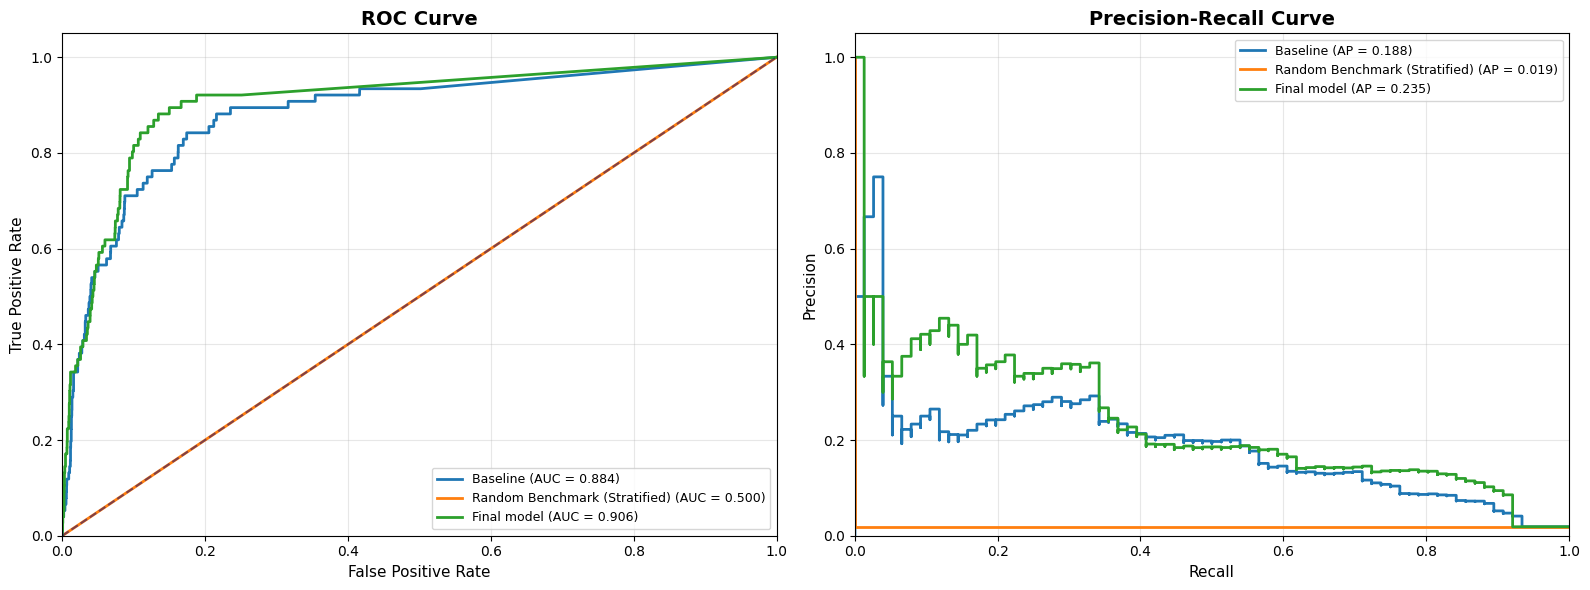


################################################################################################################################################################
                                                              FINAL RANKING (SORTED BY GLOBAL F1)                                                               
################################################################################################################################################################
                   Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                  Final model 0.808    0.351   0.361   0.342     0.906   0.400  0.382  0.419    0.672    0.313   0.342   0.289     0.888     25
                     Baseline 0.582    0.315   0.292   0.342     0.884   0.390  0.326  0.484    0.693    0.250   0.256   0.244     0.876      9
Random Benchmark (Stratified) 0.000    0.037   0.019   1.000     0.500   0.255  0.14

In [20]:
df_original.reset_index(inplace=True)
experiments_map["Final model"] = "rf_baseline"
comparison = ["Random Benchmark (Stratified)", "Baseline", "Final model"]

evaluate_experiments(
    plots_filter=comparison, 
    df_master=df_original,
    threshold_05=False, 
    experiments_map=experiments_map
)

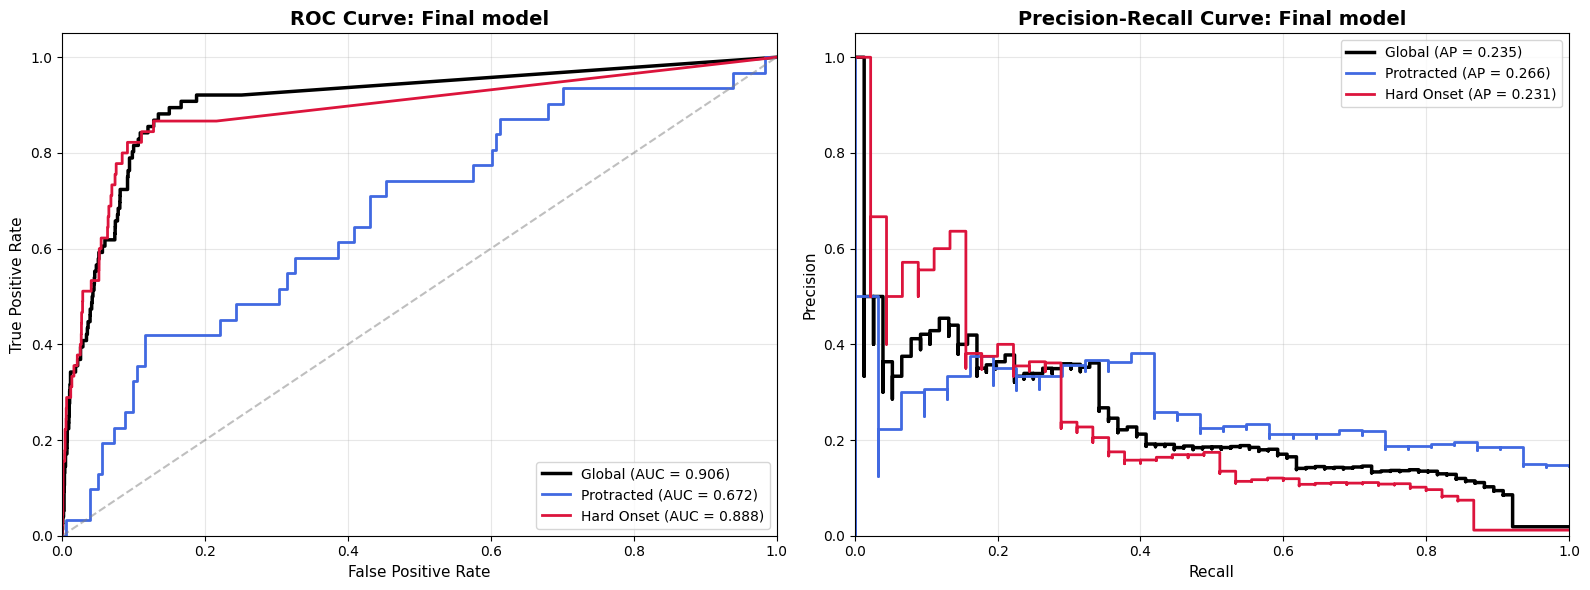

In [22]:
def plot_single_experiment_subgroups(experiment_name, df_master, results_folder="results", experiments_map=None):
    """
    Plots ROC and Precision-Recall curves for a SINGLE experiment,
    broken down by Global, Protracted, and Hard Onset subgroups.
    """
    if experiment_name not in experiments_map:
        print(f"Experiment '{experiment_name}' not found in experiments_map.")
        return
    
    prefix = experiments_map[experiment_name]
    pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
    
    if not os.path.exists(pred_file):
        print(f"Prediction file not found: {pred_file}")
        return
        
    # Load predictions
    df_preds = pd.read_csv(pred_file)
    if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
        df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
    if 'month' in df_preds.columns:
        df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')
        
    if 'is_protracted' not in df_preds.columns:
        if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
            df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Global metrics
    y_t_glob = df_preds["y_true"]
    y_p_glob = df_preds["y_prob"]
    
    fpr_g, tpr_g, _ = roc_curve(y_t_glob, y_p_glob)
    auc_g = roc_auc_score(y_t_glob, y_p_glob)
    ax_roc.plot(fpr_g, tpr_g, lw=2.5, color='black', label=f'Global (AUC = {auc_g:.3f})')
    
    prec_g, rec_g, _ = precision_recall_curve(y_t_glob, y_p_glob)
    ap_g = average_precision_score(y_t_glob, y_p_glob)
    ax_pr.plot(rec_g, prec_g, lw=2.5, color='black', drawstyle='steps-post', label=f'Global (AP = {ap_g:.3f})')
    
    # Subgroup metrics
    if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
        
        # SUBGROUP: Protracted (is_protracted = 1)
        pro_mask = df_preds['is_protracted'] == 1
        if pro_mask.sum() > 0:
            y_t_pro = df_preds.loc[pro_mask, 'y_true']
            y_p_pro = df_preds.loc[pro_mask, 'y_prob']
            
            if len(np.unique(y_t_pro)) > 1:
                fpr_p, tpr_p, _ = roc_curve(y_t_pro, y_p_pro)
                auc_p = roc_auc_score(y_t_pro, y_p_pro)
                ax_roc.plot(fpr_p, tpr_p, lw=2, color='royalblue', linestyle='-', label=f'Protracted (AUC = {auc_p:.3f})')
                
                prec_p, rec_p, _ = precision_recall_curve(y_t_pro, y_p_pro)
                ap_p = average_precision_score(y_t_pro, y_p_pro)
                ax_pr.plot(rec_p, prec_p, lw=2, color='royalblue', drawstyle='steps-post', label=f'Protracted (AP = {ap_p:.3f})')
        
        # SUBGROUP: Hard Onset (is_protracted = 0)
        hard_mask = df_preds['is_protracted'] == 0
        if hard_mask.sum() > 0:
            y_t_hard = df_preds.loc[hard_mask, 'y_true']
            y_p_hard = df_preds.loc[hard_mask, 'y_prob']
            
            if len(np.unique(y_t_hard)) > 1:
                fpr_h, tpr_h, _ = roc_curve(y_t_hard, y_p_hard)
                auc_h = roc_auc_score(y_t_hard, y_p_hard)
                ax_roc.plot(fpr_h, tpr_h, lw=2, color='crimson', linestyle='-', label=f'Hard Onset (AUC = {auc_h:.3f})')
                
                prec_h, rec_h, _ = precision_recall_curve(y_t_hard, y_p_hard)
                ap_h = average_precision_score(y_t_hard, y_p_hard)
                ax_pr.plot(rec_h, prec_h, lw=2, color='crimson', drawstyle='steps-post', label=f'Hard Onset (AP = {ap_h:.3f})')

    # Graphic formal
    ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title(f'ROC Curve: {experiment_name}', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc.set_ylabel('True Positive Rate', fontsize=11)
    ax_roc.grid(alpha=0.3)
    ax_roc.legend(loc='lower right', fontsize=10, frameon=True)

    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title(f'Precision-Recall Curve: {experiment_name}', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall', fontsize=11)
    ax_pr.set_ylabel('Precision', fontsize=11)
    ax_pr.grid(alpha=0.3)
    ax_pr.legend(loc='upper right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.show()

plot_single_experiment_subgroups(experiment_name = "Final model", df_master = df_original, results_folder="results", experiments_map=experiments_map)

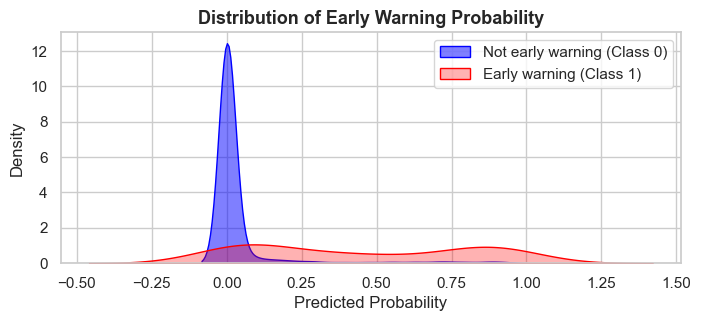

In [23]:
# Setting the aesthetic style of the plots
sns.set(style="whitegrid")

# Plotting
plt.figure(figsize=(8, 3))

# KDE plot for category 0 with the updated 'fill' parameter
sns.kdeplot(df_preds_final.loc[df_preds_final['y_true'] == 0, 'y_prob'], color="blue", fill=True, alpha=0.5, label='Not early warning (Class 0)')

# KDE plot for category 1 with the updated 'fill' parameter
sns.kdeplot(df_preds_final.loc[df_preds_final['y_true'] == 1, 'y_prob'], color="red", fill=True, alpha=0.3, label='Early warning (Class 1)')

# Adding plot title, and x and y labels
plt.title('Distribution of Early Warning Probability', fontweight='bold', fontsize=13)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')

# Adding a legend to differentiate between categories
plt.legend()
plt.show()

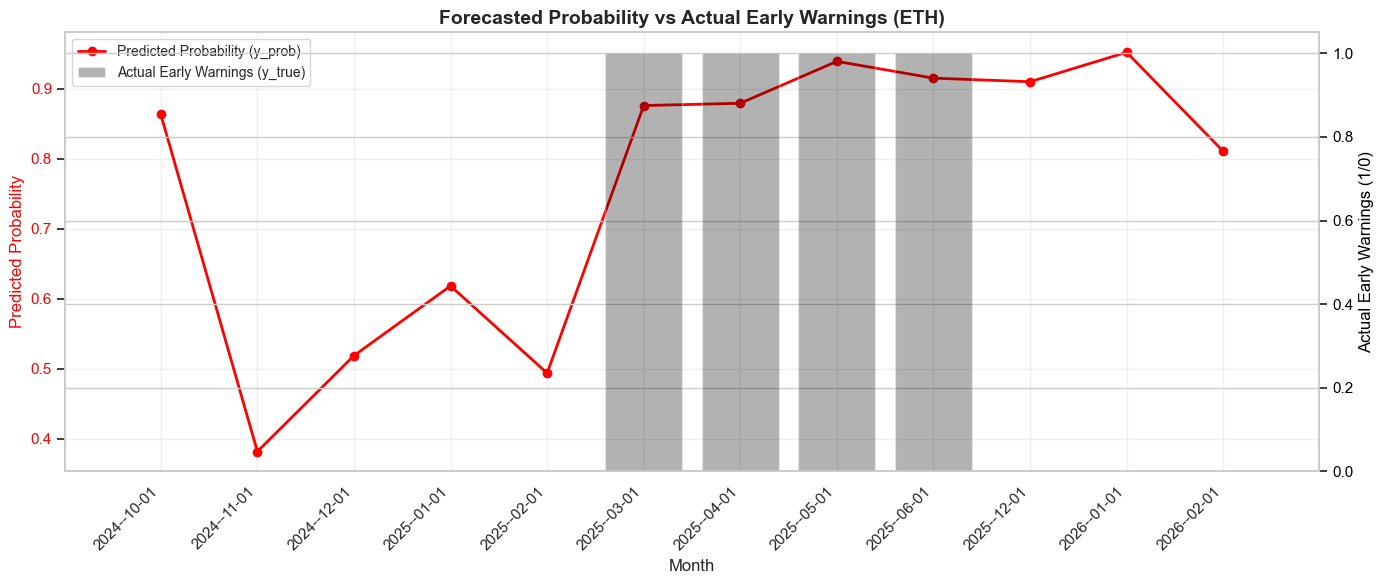

Data for ETH:
Number of observations: 12
Period range: 2024-10-01 00:00:00 to 2026-02-01 00:00:00
Mean prediction: 0.7633
Early warnings (True 1s): 4.0


In [24]:
# Filter data for a specific country
country_code = "ETH"  # Change this to any iso3 you want to visualize
country_data = df_preds_final[df_preds_final['iso3'] == country_code].sort_values('month')

# Convert period numbers to readable format (YYYYMM -> YYYY-MM)
country_data_plot = country_data.copy()
# Nota: asumo que tu columna 'month' tiene formato numérico YYYYMM, como en tu código original
country_data_plot['period_str'] = country_data_plot['month'].astype(str).apply(lambda x: f"{x[:4]}-{x[4:]}")

# Create the visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual crises (y_true) as black bars (secondary axis for better visibility)
ax2 = ax.twinx()
ax2.bar(range(len(country_data_plot)), country_data_plot['y_true'], alpha=0.3, color='black', label='Actual Early Warnings (y_true)')

# Plot predicted probabilities (y_prob) as a line on primary axis
ax.plot(range(len(country_data_plot)), country_data_plot['y_prob'], color='red', linewidth=2, marker='o', label='Predicted Probability (y_prob)')

# Labels and formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Predicted Probability', fontsize=12, color='red')
ax2.set_ylabel('Actual Early Warnings (1/0)', fontsize=12, color='black')
ax.set_title(f'Forecasted Probability vs Actual Early Warnings ({country_code})', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='black')
ax.grid(True, alpha=0.3)

# Set x-axis ticks to show every 3 months (or fewer if fewer periods)
tick_step = max(1, len(country_data_plot) // 8)
ax.set_xticks(range(0, len(country_data_plot), tick_step))
ax.set_xticklabels(country_data_plot['period_str'].iloc[::tick_step], rotation=45, ha='right')

# Add legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Data for {country_code}:")
print(f"Number of observations: {len(country_data)}")
print(f"Period range: {country_data['month'].min()} to {country_data['month'].max()}")
print(f"Mean prediction: {country_data['y_prob'].mean():.4f}")
print(f"Early warnings (True 1s): {country_data['y_true'].sum()}")

Full model separation plot:


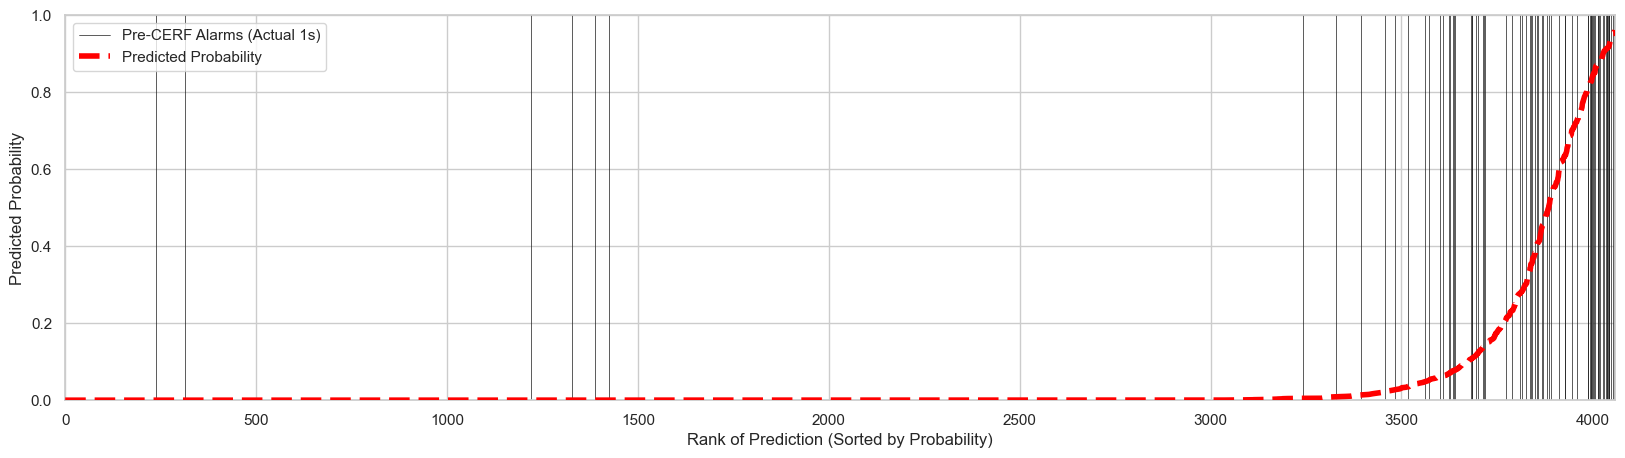

In [25]:
def separation_plot(pdata, alpha=1):
    '''
    Display observed events against predicted probabilities for binary classification problems
    '''
    df = pdata.dropna(subset=[pdata.columns[0], pdata.columns[1]]).copy()
    df.columns = ['y', 'yhat']
    
    # Order by predicted probabilities (yhat) in ascending order
    df = df.sort_values('yhat').reset_index(drop=True)

    # Identify where the actual events (1s) are located in the sorted DataFrame
    events = df[df['y'] == 1]
    evals = events.index.values

    plt.figure(figsize=(20, 5))
    ax = plt.gca()
    ax.set_xlim([0, len(df)])
    ax.set_ylim([0, 1])

    # Plot vertical lines for actual events (1s) in the data
    rr = 0
    for i in evals:
        if rr == 0:
            ax.axvline(x=i, linewidth=0.5, linestyle='-', color='k', alpha=alpha, label='Pre-CERF Alarms (Actual 1s)', zorder=2)
            rr = 1
        else:
            ax.axvline(x=i, linewidth=0.5, linestyle='-', color='k', alpha=alpha, zorder=1)

    ax.plot(df['yhat'], linestyle='--', color='red', lw=4, label='Predicted Probability', zorder=3)
    plt.ylabel('Predicted Probability')
    plt.xlabel('Rank of Prediction (Sorted by Probability)')
    ax.legend(loc="upper left", frameon=True, facecolor='white')
        
    plt.show()
    plt.close()

print('Full model separation plot:')

sep_data = df_preds_final[['y_true', 'y_prob']]
name = None 

separation_plot(sep_data, name)

#### 3.2 FEATURE IMPORTANCE AND SHAP VALUES

In [26]:
df_importance = pd.DataFrame({
    'feature': X_full.columns,
    'importance': model_final.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Feature importance:")
display(df_importance)

Feature importance:


,feature,importance
0,disp_6m_avg,0.172694
24,risk_12,0.115473
6,fat_6m_avg,0.113926
2,disp_3m_avg,0.085573
3,fatalities_lag1,0.081011
23,risk_3,0.079831
5,fat_3m_avg,0.062163
1,rolling_3m_displacements,0.053704
15,INFORM,0.042477
8,fatalities_lag2,0.029027


In [27]:
explainer = shap.TreeExplainer(model_final)

# Compute the SHAP values for your matrix X
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_full)

# Extract the positive class (1) safely
if isinstance(shap_values, list):
    print("Old SHAP format detected (List of arrays).")
    shap_values_positiva = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("New SHAP format detected (3D Array).")
    shap_values_positiva = shap_values[:, :, 1]
else:
    print("Old 2D format detected.")
    shap_values_positiva = shap_values

# Plotting the Summary Plot 
print("Generating Summary Plot...")
ordered_features = df_importance['feature'].tolist()
X_ordered = X_full[ordered_features]
shap_df = pd.DataFrame(shap_values_positiva, columns=X_full.columns)
shap_values_ordered = shap_df[ordered_features].values
shap.summary_plot(
    shap_values_ordered, 
    X_ordered, 
    sort=False, 
    max_display=len(ordered_features) 
)

NameError: name 'shap' is not defined

Finally we are going to compute the shap importance for the protracted and the hard on set cases separately:

In [18]:
X_test_shap = df_final_test[FINAL_FEATURES]
idx_protracted = df_final_test['is_protracted'] == 1
idx_hard = df_final_test['is_protracted'] == 0
X_protracted = X_test_shap[idx_protracted]
X_hard = X_test_shap[idx_hard]

# Compute the SHAP values for the Protracted and Hard Onset subgroups
print("Computing SHAP values for Protracted...")
shap_protracted = explainer.shap_values(X_protracted)
if isinstance(shap_protracted, list): 
    shap_protracted = shap_protracted[1]
elif len(shap_protracted.shape) == 3: 
    shap_protracted = shap_protracted[:, :, 1]

print("Computing SHAP values for Hard Onset...")
shap_hard = explainer.shap_values(X_hard)

if isinstance(shap_hard, list): 
    shap_hard = shap_hard[1]
elif len(shap_hard.shape) == 3: 
    shap_hard = shap_hard[:, :, 1]

# Compute the mean absolute SHAP values for each feature in both subgroups
imp_protracted = np.abs(shap_protracted).mean(axis=0)
imp_hard = np.abs(shap_hard).mean(axis=0)

df_imp_protracted = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance_shap': imp_protracted
}).sort_values(by='importance_shap', ascending=False)

df_imp_hard = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance_shap': imp_hard
}).sort_values(by='importance_shap', ascending=False)

print("\n--- Feature Importance SHAP - PROTRACTED ---")
display(df_imp_protracted.head(10))

print("\n--- Feature Importance SHAP - HARD ONSET ---")
display(df_imp_hard.head(10))

Computing SHAP values for Protracted...
Computing SHAP values for Hard Onset...

--- Feature Importance SHAP - PROTRACTED ---


,feature,importance_shap
0,disp_6m_avg,0.103370
2,disp_3m_avg,0.052063
1,rolling_3m_displacements,0.042252
24,risk_12,0.039678
6,fat_6m_avg,0.038254
23,risk_3,0.023299
12,disp_change_lag2_to_now,0.022524
3,fatalities_lag1,0.022374
15,INFORM,0.021102
5,fat_3m_avg,0.020597



--- Feature Importance SHAP - HARD ONSET ---


,feature,importance_shap
0,disp_6m_avg,0.077741
24,risk_12,0.069427
23,risk_3,0.038177
3,fatalities_lag1,0.037593
6,fat_6m_avg,0.034278
5,fat_3m_avg,0.027605
7,acled_disp_score_max,0.026961
2,disp_3m_avg,0.024781
10,conflict_severity_index,0.023222
1,rolling_3m_displacements,0.023044


#### 3.3 ERROR ANALYSIS

In [28]:
# Drop rows where we don't have predictions or true values
df_evaluation = df_final_test.dropna(subset=['y_true', 'y_pred'])

# Store False Negatives and True Positives for the analyses below
false_negatives = df_evaluation[
    (df_evaluation['y_true'] == 1) &
    (df_evaluation['y_pred'] == 0)
].copy()

true_positives = df_evaluation[
    (df_evaluation['y_true'] == 1) &
    (df_evaluation['y_pred'] == 1)
].copy()

false_positives = df_evaluation[
    (df_evaluation['y_true'] == 0) &
    (df_evaluation['y_pred'] == 1)
].copy()

In [20]:
print("FALSE POSITIVES:")
print(len(false_positives))

print("FALSE NEGATIVES:")
print(len(false_negatives))

print("TRUE POSITIVES:")
print(len(true_positives))

print("\n\n================ METRICS REPORT ================\n")
print(classification_report(df_evaluation['y_true'], df_evaluation['y_pred']))

FALSE POSITIVES:
46
FALSE NEGATIVES:
50
TRUE POSITIVES:
26


================ METRICS REPORT ================

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3984
         1.0       0.36      0.34      0.35        76

    accuracy                           0.98      4060
   macro avg       0.67      0.67      0.67      4060
weighted avg       0.98      0.98      0.98      4060



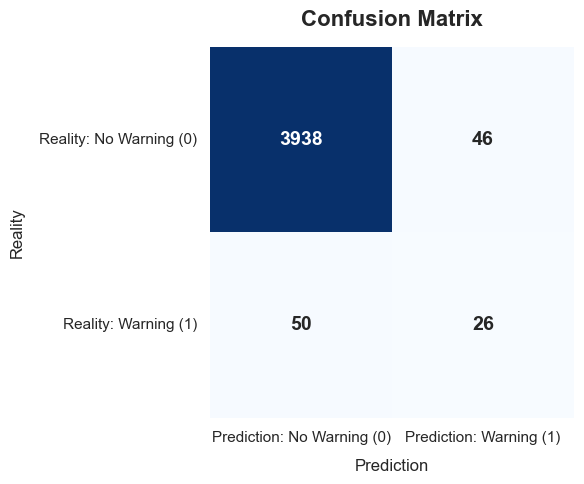

In [21]:
# Comput the confusion matrix
cm = confusion_matrix(df_evaluation['y_true'], df_evaluation['y_pred'])


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediction: No Warning (0)', 'Prediction: Warning (1)'],
            yticklabels=['Reality: No Warning (0)', 'Reality: Warning (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Prediction', fontsize=12, labelpad=10)
plt.ylabel('Reality', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Predicted probabilities of false negatives:

count    50.000000
mean      0.219571
std       0.217798
min       0.000000
25%       0.049120
50%       0.119645
75%       0.376186
max       0.722299
Name: y_prob, dtype: float64


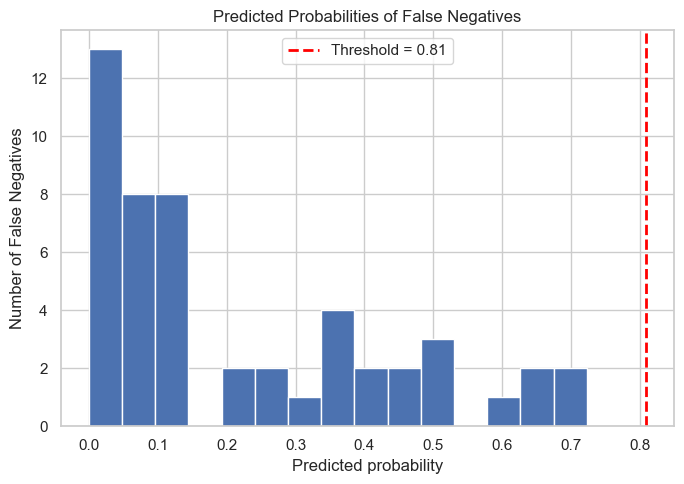

In [29]:
print(false_negatives['y_prob'].describe())
plt.figure(figsize=(7,5))
plt.hist(false_negatives['y_prob'], bins=15)
plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Threshold = {best_threshold:.2f}'
)

plt.xlabel('Predicted probability')
plt.ylabel('Number of False Negatives')
plt.title('Predicted Probabilities of False Negatives')

plt.legend()

plt.tight_layout()
plt.show()

False negatives vs true positives:

,False Negatives,True Positives
fatalities,136.000000,377.50000
event_count,574.000000,213.00000
monthly_displacement,0.000000,17547.98848
risk_3,0.235806,0.28426
INFORM,5.300000,7.20000


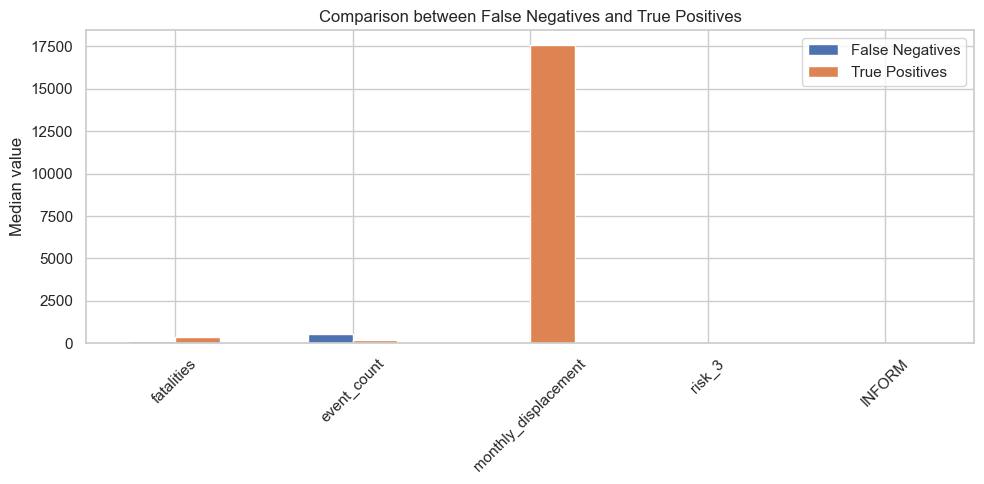

In [30]:
variables = [
    'fatalities',
    'event_count',
    'monthly_displacement',
    'risk_3',
    'INFORM'
]

comparison = pd.DataFrame({
    'False Negatives': false_negatives[variables].median(),
    'True Positives': true_positives[variables].median()
})

display(comparison)

comparison.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel("Median value")
plt.title("Comparison between False Negatives and True Positives")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

False negatives by crisis type compared to total positive observations

In [31]:
fn_summary = (
    df_evaluation[df_evaluation["y_true"] == 1]
    .groupby("is_protracted")
    .agg(
        Total_Positive=("y_true", "size"),
        False_Negatives=("y_pred", lambda x: (x == 0).sum())
    )
)

fn_summary["FN Rate"] = (
    100 * fn_summary["False_Negatives"] / fn_summary["Total_Positive"]
).round(1)

display(fn_summary)

,Total_Positive,False_Negatives,FN Rate
is_protracted,,,
0,45,32,71.1
1,31,18,58.1


Distance to elegibility treshold:

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
False Negatives,50.0,38404.532659,147347.381263,0.000000,0.000000,531.500000,20323.428572,840929.285743
True Positives,26.0,48410.073118,14668.350333,30057.110185,39534.750008,42954.870195,55000.000006,83562.500002


<Figure size 700x500 with 0 Axes>

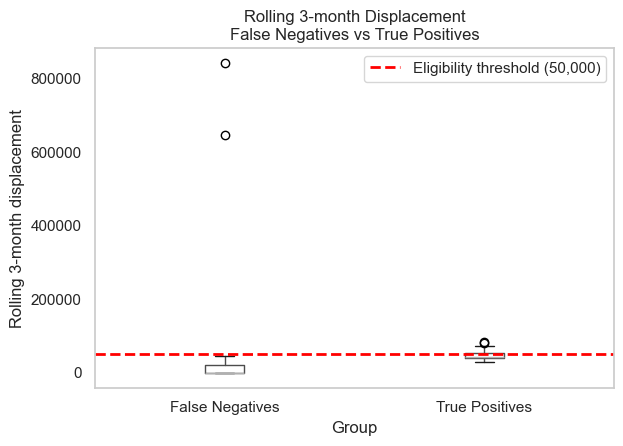

In [32]:
comparison_df = pd.concat([
    pd.DataFrame({
        "Group": "False Negatives",
        "Rolling 3-month displacement": false_negatives["rolling_3m_displacements"]
    }),
    pd.DataFrame({
        "Group": "True Positives",
        "Rolling 3-month displacement": true_positives["rolling_3m_displacements"]
    })
])

# Summary statistics
summary = comparison_df.groupby("Group")["Rolling 3-month displacement"].describe()
display(summary)

# Boxplot
plt.figure(figsize=(7,5))

comparison_df.boxplot(
    column="Rolling 3-month displacement",
    by="Group",
    grid=False
)

plt.axhline(
    50000,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Eligibility threshold (50,000)"
)

plt.ylabel("Rolling 3-month displacement")
plt.title("Rolling 3-month Displacement\nFalse Negatives vs True Positives")
plt.suptitle("")  # Removes pandas automatic title

plt.legend()

plt.tight_layout()
plt.show()

In [33]:
df_final_test.reset_index(inplace=True)

In [35]:
def plot_country(country):
    country_df = df_final_test[df_final_test['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['risk_12'],
             color='pink', linewidth=1.5, linestyle='--', label='Risk_12')
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    

    # True Positives (TP: pred=1 i true=1) -> Green dashed
    true_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 1)]['month']
    for month in true_pos:
        ax1.axvline(x=month, color='green', alpha=0.8, linewidth=2, linestyle='--', label='TP (Correct Alarm)')

    # False Positives (FP: pred=1 i true=0) -> Orange dashed
    false_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 0)]['month']
    for month in false_pos:
        ax1.axvline(x=month, color='darkorange', alpha=0.8, linewidth=2, linestyle='--', label='FP (False Alarm)')

    # False Negatives (FN: pred=0 i true=1) -> Red dashed
    false_neg = country_df[(country_df['y_pred'] == 0) & (country_df['y_true'] == 1)]['month']
    for month in false_neg:
        ax1.axvline(x=month, color='red', alpha=0.8, linewidth=2, linestyle='--', label='FN (Undetected Crisis)')

    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible 
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.1, linewidth=15, label='Allocation Eligible')

    # Delete duplicate legend entries
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

countries = sorted(df_final_test['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='AFG', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS…

<function __main__.plot_country(country)>

### 4. Robustness checks 

To measure heterogeneity, that is, how our model perfoms in a different context, we will perform 3 robustness checks: 
 - Separate blocks
 - XG Boost 
 - Continents

#### 4.1 Feature blocks

In [27]:
# ROBUSTNESS CHECK: Run the final model separately for each block that makes up FINAL_FEATURES, with Global/Protracted/Hard 
# Onset breakdown

best_features_derived_humanitarian_impact = ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals = ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']
FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

blocks_to_test = {
    "Derived Humanitarian Impact BEST": best_features_derived_humanitarian_impact,
    "INFORM": ["INFORM"],
    "CERF Signals": features_cerf_signals,
    "Risk (risk_3 + risk_12)": ["risk_3", "risk_12"],
    "FINAL_FEATURES (all combined)": FINAL_FEATURES,
}

MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    """Returns F1, Precision, Recall, AUC for a given subset."""
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    fp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3), "AUC": round(auc, 3)}

robustness_results = []

for block_name, feature_list in blocks_to_test.items():

    print("\n" + "="*60)
    print(f"BLOCK: {block_name} ({len(feature_list)} features)")
    print("="*60)

    df_prep = df_original.copy()
    df_prep = df_prep.set_index(["iso3", "month"])

    last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
    df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
    df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

    cols_to_keep = feature_list + [TARGET_COL, 'is_protracted']
    df_clean = df_prep[cols_to_keep].dropna(subset=feature_list + [TARGET_COL])

    X_block = df_clean[feature_list]
    y_block = df_clean[TARGET_COL]
    protracted_block = df_clean['is_protracted']
    periods_block = df_clean.index.get_level_values('month')

    panel_split = PanelSplit(periods=periods_block, n_splits=24, test_size=1, gap=1)
    clf_block = RandomForestClassifier(**MODEL_PARAMS)

    all_y_true, all_y_prob, all_protracted = [], [], []

    for train_idx, test_idx in panel_split.split(X_block):
        X_train, X_test = X_block.iloc[train_idx], X_block.iloc[test_idx]
        y_train, y_test = y_block.iloc[train_idx], y_block.iloc[test_idx]
        prot_test = protracted_block.iloc[test_idx]

        clf_block.fit(X_train, y_train)
        probs = clf_block.predict_proba(X_test)[:, 1]

        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)
        all_protracted.extend(prot_test.values)

    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)
    all_protracted = np.array(all_protracted)

    # Optimal threshold by F1 (computed on GLOBAL, same as main model)
    precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    all_y_pred = (all_y_prob >= best_threshold).astype(int)

    # GLOBAL
    global_metrics = compute_subgroup_metrics(all_y_true, all_y_prob, all_y_pred)
    print(f"GLOBAL: F1={global_metrics['F1']} | P={global_metrics['Precision']} | R={global_metrics['Recall']} | AUC={global_metrics['AUC']}")

    # PROTRACTED (is_protracted == 1)
    mask_prot = all_protracted == 1
    prot_metrics = compute_subgroup_metrics(all_y_true[mask_prot], all_y_prob[mask_prot], all_y_pred[mask_prot])
    print(f"PROTRACTED: F1={prot_metrics['F1']} | P={prot_metrics['Precision']} | R={prot_metrics['Recall']} | AUC={prot_metrics['AUC']}")

    # HARD ONSET (is_protracted == 0)
    mask_hard = all_protracted == 0
    hard_metrics = compute_subgroup_metrics(all_y_true[mask_hard], all_y_prob[mask_hard], all_y_pred[mask_hard])
    print(f"HARD ONSET: F1={hard_metrics['F1']} | P={hard_metrics['Precision']} | R={hard_metrics['Recall']} | AUC={hard_metrics['AUC']}")
    print(f"Optimal Threshold: {best_threshold:.3f}")

    robustness_results.append({
        "Block": block_name,
        "N_Features": len(feature_list),
        "Threshold": round(best_threshold, 3),
        "Glob_F1": global_metrics["F1"], "Glob_P": global_metrics["Precision"], "Glob_R": global_metrics["Recall"], "Glob_AUC": global_metrics["AUC"],
        "Prot_F1": prot_metrics["F1"], "Prot_P": prot_metrics["Precision"], "Prot_R": prot_metrics["Recall"], "Prot_AUC": prot_metrics["AUC"],
        "Hard_F1": hard_metrics["F1"], "Hard_P": hard_metrics["Precision"], "Hard_R": hard_metrics["Recall"], "Hard_AUC": hard_metrics["AUC"],
    })

df_robustness = pd.DataFrame(robustness_results)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
display(df_robustness)

df_robustness.to_csv(os.path.join(RESULTS_FOLDER, "robustness_by_block.csv"), index=False)


BLOCK: Derived Humanitarian Impact BEST (15 features)
GLOBAL: F1=0.312 | P=0.298 | R=0.329 | AUC=0.886
PROTRACTED: F1=0.343 | P=0.308 | R=0.387 | AUC=0.654
HARD ONSET: F1=0.289 | P=0.289 | R=0.289 | AUC=0.874
Optimal Threshold: 0.755

BLOCK: INFORM (1 features)
GLOBAL: F1=0.232 | P=0.158 | R=0.434 | AUC=0.851
PROTRACTED: F1=0.256 | P=0.167 | R=0.548 | AUC=0.487
HARD ONSET: F1=0.211 | P=0.15 | R=0.356 | AUC=0.857
Optimal Threshold: 0.821

BLOCK: CERF Signals (7 features)
GLOBAL: F1=0.153 | P=0.085 | R=0.789 | AUC=0.807
PROTRACTED: F1=0.244 | P=0.143 | R=0.839 | AUC=0.467
HARD ONSET: F1=0.119 | P=0.064 | R=0.756 | AUC=0.795
Optimal Threshold: 0.548

BLOCK: Risk (risk_3 + risk_12) (2 features)
GLOBAL: F1=0.204 | P=0.124 | R=0.566 | AUC=0.858
PROTRACTED: F1=0.308 | P=0.188 | R=0.839 | AUC=0.549
HARD ONSET: F1=0.134 | P=0.082 | R=0.378 | AUC=0.82
Optimal Threshold: 0.393

BLOCK: FINAL_FEATURES (all combined) (25 features)
GLOBAL: F1=0.351 | P=0.361 | R=0.342 | AUC=0.906
PROTRACTED: F1=0.4 

,Block,N_Features,Threshold,Glob_F1,Glob_P,Glob_R,Glob_AUC,Prot_F1,Prot_P,Prot_R,Prot_AUC,Hard_F1,Hard_P,Hard_R,Hard_AUC
0,Derived Humanitarian Impact BEST,15,0.755,0.312,0.298,0.329,0.886,0.343,0.308,0.387,0.654,0.289,0.289,0.289,0.874
1,INFORM,1,0.821,0.232,0.158,0.434,0.851,0.256,0.167,0.548,0.487,0.211,0.150,0.356,0.857
2,CERF Signals,7,0.548,0.153,0.085,0.789,0.807,0.244,0.143,0.839,0.467,0.119,0.064,0.756,0.795
3,Risk (risk_3 + risk_12),2,0.393,0.204,0.124,0.566,0.858,0.308,0.188,0.839,0.549,0.134,0.082,0.378,0.820
4,FINAL_FEATURES (all combined),25,0.808,0.351,0.361,0.342,0.906,0.400,0.382,0.419,0.672,0.313,0.342,0.289,0.888


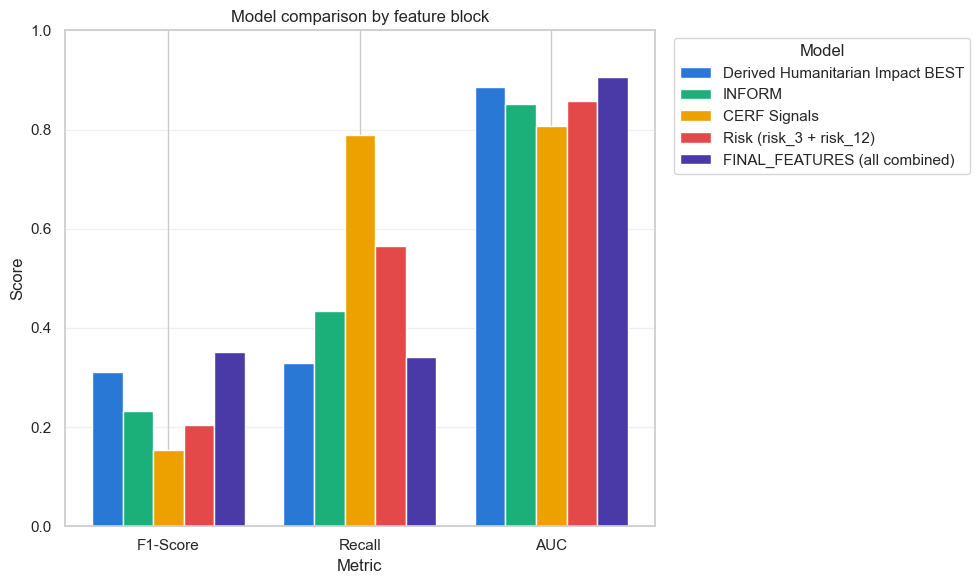

In [28]:
# Uses the df_robustness dataframe already generated by the robustness check code
metrics_to_plot = ['Glob_F1', 'Glob_R', 'Glob_AUC']
metric_labels = ['F1-Score', 'Recall', 'AUC']

models = df_robustness['Block'].tolist()
n_models = len(models)
colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948', '#4a3aa7']

x = np.arange(len(metrics_to_plot))  
width = 0.8 / n_models 

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    values = df_robustness.loc[df_robustness['Block'] == model, metrics_to_plot].values.flatten()
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model comparison by feature block')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/robustness_comparison.png', dpi=150)
plt.show()

##### Key findings — robustness check by feature block

- **FINAL_FEATURES (combined, 25 features) achieves the best F1-score (0.338)** of all configurations tested, confirming that combining blocks outperforms any single block alone.
- **No individual block matches the combined model on F1**: Derived Humanitarian Impact BEST comes closest (0.312), followed by INFORM (0.232), Risk (0.204), and CERF Signals (0.153).
- **Recall and F1 trade off sharply across blocks**: CERF Signals alone reaches the highest recall (0.789) but the lowest F1 (0.153) and precision (0.085), confirming it generates many false positives when used in isolation.
- **Risk (risk_3 + risk_12) shows the same pattern**, with only 2 features it reaches 0.566 recall but just 0.204 F1 , useful as a recall booster within the combined model, not as an alone predictor.
- **Derived Humanitarian Impact BEST is the strongest individual block**, with the best precision (0.298) and F1 (0.312) among single blocks, and the highest AUC (0.886) of the four individual blocks.
- **AUC is high and stable across all blocks (0.808–0.906)**, including the weakest blocks by F1. This shows all blocks carry discriminative signal, but the choice of features still matters for translating that signal into the optimal-threshold F1.
- **Protracted vs. Hard Onset**: every block performs better on Protracted cases (F1 0.327–0.429) than on Hard Onset cases (F1 0.135–0.323), with the gap most pronounced in CERF Signals (Prot_F1 0.329 vs Hard_F1 0.135). This suggests hard onset crises remain harder to predict regardless of feature block.
- **FINAL_FEATURES leads on both subgroups**: Protracted F1 = 0.417 and Hard Onset F1 = 0.323 ,both the highest among all five models, reinforcing that the combined feature set generalizes better across crisis types, not just on the global metric.

In terms of robustness, this results suggests that the final model does not rely on a single block of variables to perform well. Each individual block on its own is not good (F1 ranging from 0.153 to 0.312), but the combined model outperforms even the best individual block (0.338 vs 0.312), showing that the blocks are complementary rather than redundant. This works like a panel of specialists rather than a single expert: each block captures a different angle of the problem, and their combined predictions compensate for each other's individual weaknesses. As a result, the model is less vulnerable to any single data source becoming unreliable or unavailable, since its performance does not hinge on one particular block.

#### 4.2 XG BOOST

In [29]:
# ROBUSTNESS CHECK: XGBoost vs Random Forest on FINAL_FEATURES
from xgboost import XGBClassifier

best_features_derived_humanitarian_impact = ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals = ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']
FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

# Default XGBoost params (no tuning) -- class imbalance handled via scale_pos_weight
last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

cols_to_keep = FINAL_FEATURES + [TARGET_COL, 'is_protracted']
df_clean = df_prep[cols_to_keep].dropna(subset=FINAL_FEATURES + [TARGET_COL])

X_xgb = df_clean[FINAL_FEATURES]
y_xgb = df_clean[TARGET_COL]
protracted_xgb = df_clean['is_protracted']
periods_xgb = df_clean.index.get_level_values('month')

# scale_pos_weight mirrors class_weight='balanced' used in the Random Forest
scale_pos_weight = (y_xgb == 0).sum() / (y_xgb == 1).sum()

XGB_PARAMS = {
    'n_estimators': 200,
    'max_depth': 6,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss'
}

panel_split = PanelSplit(periods=periods_xgb, n_splits=24, test_size=1, gap=1)
clf_xgb = XGBClassifier(**XGB_PARAMS)

all_y_true, all_y_prob, all_protracted = [], [], []

for train_idx, test_idx in panel_split.split(X_xgb):
    X_train, X_test = X_xgb.iloc[train_idx], X_xgb.iloc[test_idx]
    y_train, y_test = y_xgb.iloc[train_idx], y_xgb.iloc[test_idx]
    prot_test = protracted_xgb.iloc[test_idx]

    clf_xgb.fit(X_train, y_train)
    probs = clf_xgb.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_protracted.extend(prot_test.values)

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_protracted = np.array(all_protracted)

# Optimal threshold by F1 (same approach as the Random Forest model)
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
all_y_pred = (all_y_prob >= best_threshold).astype(int)

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    fp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3), "AUC": round(auc, 3)}

global_metrics = compute_subgroup_metrics(all_y_true, all_y_prob, all_y_pred)

mask_prot = all_protracted == 1
prot_metrics = compute_subgroup_metrics(all_y_true[mask_prot], all_y_prob[mask_prot], all_y_pred[mask_prot])

mask_hard = all_protracted == 0
hard_metrics = compute_subgroup_metrics(all_y_true[mask_hard], all_y_prob[mask_hard], all_y_pred[mask_hard])

print("="*60)
print(f"XGBOOST -- FINAL_FEATURES ({len(FINAL_FEATURES)} features)")
print("="*60)
print(f"Optimal Threshold: {best_threshold:.3f}")
print("-"*60)
print(f"GLOBAL: F1={global_metrics['F1']} | P={global_metrics['Precision']} | R={global_metrics['Recall']} | AUC={global_metrics['AUC']}")
print(f"PROTRACTED: F1={prot_metrics['F1']} | P={prot_metrics['Precision']} | R={prot_metrics['Recall']} | AUC={prot_metrics['AUC']}")
print(f"HARD ONSET: F1={hard_metrics['F1']} | P={hard_metrics['Precision']} | R={hard_metrics['Recall']} | AUC={hard_metrics['AUC']}")

df_xgb_results = pd.DataFrame([{
    "Model": "XGBoost (default)",
    "N_Features": len(FINAL_FEATURES),
    "Threshold": round(best_threshold, 3),
    "Glob_F1": global_metrics["F1"], "Glob_P": global_metrics["Precision"], "Glob_R": global_metrics["Recall"], "Glob_AUC": global_metrics["AUC"],
    "Prot_F1": prot_metrics["F1"], "Prot_P": prot_metrics["Precision"], "Prot_R": prot_metrics["Recall"], "Prot_AUC": prot_metrics["AUC"],
    "Hard_F1": hard_metrics["F1"], "Hard_P": hard_metrics["Precision"], "Hard_R": hard_metrics["Recall"], "Hard_AUC": hard_metrics["AUC"],
}])

df_xgb_results.to_csv(os.path.join(RESULTS_FOLDER, "xgboost_final_features.csv"), index=False)
display(df_xgb_results)

XGBOOST -- FINAL_FEATURES (25 features)
Optimal Threshold: 0.039
------------------------------------------------------------
GLOBAL: F1=0.3 | P=0.223 | R=0.461 | AUC=0.889
PROTRACTED: F1=0.305 | P=0.216 | R=0.516 | AUC=0.636
HARD ONSET: F1=0.297 | P=0.229 | R=0.422 | AUC=0.866


,Model,N_Features,Threshold,Glob_F1,Glob_P,Glob_R,Glob_AUC,Prot_F1,Prot_P,Prot_R,Prot_AUC,Hard_F1,Hard_P,Hard_R,Hard_AUC
0,XGBoost (default),25,0.039,0.3,0.223,0.461,0.889,0.305,0.216,0.516,0.636,0.297,0.229,0.422,0.866


MODEL COMPARISON -- Random Forest vs XGBoost (FINAL_FEATURES)


,Model,N_Features,Threshold,F1,Precision,Recall,AUC
0,Random Forest,25,0.808,0.351,0.361,0.342,0.906
1,XGBoost,25,0.039,0.300,0.223,0.461,0.889


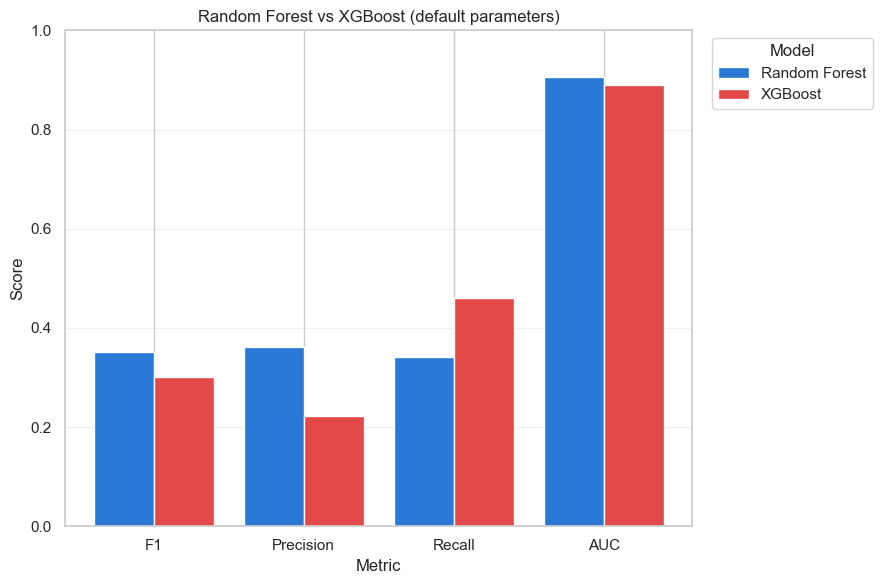

In [30]:
# COMPARISON TABLE AND CHART: Random Forest vs XGBoost (Global metrics, FINAL_FEATURES)

# Build comparison table from the two results already computed:
# df_robustness (Random Forest, row "FINAL_FEATURES (all combined)")
# df_xgb_results (XGBoost, row "XGBoost (default)")

rf_row = df_robustness[df_robustness['Block'] == 'FINAL_FEATURES (all combined)'].iloc[0]
xgb_row = df_xgb_results.iloc[0]

df_model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "N_Features": rf_row["N_Features"],
        "Threshold": rf_row["Threshold"],
        "F1": rf_row["Glob_F1"],
        "Precision": rf_row["Glob_P"],
        "Recall": rf_row["Glob_R"],
        "AUC": rf_row["Glob_AUC"],
    },
    {
        "Model": "XGBoost",
        "N_Features": xgb_row["N_Features"],
        "Threshold": xgb_row["Threshold"],
        "F1": xgb_row["Glob_F1"],
        "Precision": xgb_row["Glob_P"],
        "Recall": xgb_row["Glob_R"],
        "AUC": xgb_row["Glob_AUC"],
    },
])

print("="*60)
print("MODEL COMPARISON -- Random Forest vs XGBoost (FINAL_FEATURES)")
print("="*60)
display(df_model_comparison)

df_model_comparison.to_csv(os.path.join(RESULTS_FOLDER, "rf_vs_xgb_comparison.csv"), index=False)

# CHART: grouped bar, metrics on X axis, model as legend
metrics_to_plot = ['F1', 'Precision', 'Recall', 'AUC']
models = df_model_comparison['Model'].tolist()
n_models = len(models)

colors = ['#2a78d6', '#e34948']  
x = np.arange(len(metrics_to_plot))
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(9, 6))

for i, model in enumerate(models):
    values = df_model_comparison.loc[df_model_comparison['Model'] == model, metrics_to_plot].values.flatten()
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Random Forest vs XGBoost (default parameters)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/rf_vs_xgb_comparison.png', dpi=150)
plt.show()

##### XGBoost robustness check — Main Findings
Random Forest outperforms XGBoost on F1 (0.338 vs 0.293), precision (0.333 vs 0.199), and AUC (0.906 vs 0.879), both under default parameters with no tuning. XGBoost achieves higher recall (0.553 vs 0.342), but at the cost of far more false positives. XGBoost's optimal threshold is extremely low (0.009), indicating its predicted probabilities are poorly calibrated for this task without tuning , it needs almost any signal to flag a positive case.

**Implication for robustness**: the final model choice (Random Forest) is not arbitrary. Under the same conditions used to select the original model (default parameters, no tuning), it outperforms a reasonable alternative algorithm. This strengthens confidence that the model's performance reflects the underlying signal in the data, not a lucky choice of algorithm.

#### 4.3 Continents

In [31]:
import pycountry_convert as pc

def iso3_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        continent_code = pc.country_alpha2_to_continent_code(iso2)
        continent_map = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'OC': 'Oceania',
        }
        # Both North and South America codes map to a single "America" region
        if continent_code in ('NA', 'SA'):
            return 'America'
        return continent_map.get(continent_code, 'Unknown')
    except:
        return 'Unknown'

iso3_list = df_prep.index.get_level_values('iso3').unique()
continent_mapping = {iso3: iso3_to_continent(iso3) for iso3 in iso3_list}

continent_mapping['TLS'] = 'Asia'

df_prep['continent'] = df_prep.index.get_level_values('iso3').map(continent_mapping)

print(df_prep.reset_index()[['iso3', 'continent']].drop_duplicates()['continent'].value_counts())

continent
Africa     52
Asia       48
Europe     39
America    29
Oceania     8
Name: count, dtype: int64


In [32]:
# Show example countries per region
df_regions = df_prep.reset_index()[['iso3', 'continent']].drop_duplicates()

for region in df_regions['continent'].unique():
    countries = df_regions[df_regions['continent'] == region]['iso3'].tolist()
    print(f"{region} ({len(countries)} countries):")
    print(countries)
    print()

Asia (48 countries):
['AFG', 'ARE', 'ARM', 'AZE', 'BGD', 'BHR', 'BRN', 'BTN', 'CHN', 'CYP', 'GEO', 'IDN', 'IND', 'IRN', 'IRQ', 'ISR', 'JOR', 'JPN', 'KAZ', 'KGZ', 'KHM', 'KOR', 'KWT', 'LAO', 'LBN', 'LKA', 'MDV', 'MMR', 'MNG', 'MYS', 'NPL', 'OMN', 'PAK', 'PHL', 'PRK', 'PSE', 'QAT', 'SAU', 'SGP', 'SYR', 'THA', 'TJK', 'TKM', 'TLS', 'TUR', 'UZB', 'VNM', 'YEM']

Africa (52 countries):
['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COM', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']

Europe (39 countries):
['ALB', 'AUT', 'BEL', 'BGR', 'BIH', 'BLR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LTU', 'LUX', 'LVA', 'MDA', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'PRT', 'ROU

In [33]:
# Proportion of class 1 (target_2m) by region
df_check = df_prep.reset_index()

class_balance = df_check.groupby('continent')['target_2m'].agg(
    total_obs='count',
    positive_cases='sum',
    proportion_class_1='mean'
).round(4)

class_balance = class_balance.sort_values('proportion_class_1', ascending=False)
print(class_balance)

           total_obs  positive_cases  proportion_class_1
continent                                               
Africa          4749           106.0              0.0223
Asia            4548            88.0              0.0193
America         2831            10.0              0.0035
Europe          3817             8.0              0.0021
Oceania          784             0.0              0.0000


In [34]:
# ROBUSTNESS CHECK: Final model performance by region (using predictions already generated by FINAL_FEATURES run)

# Need iso3 alongside the existing prediction arrays to map each row to a region
# Re-run the FINAL_FEATURES prediction loop, this time also tracking iso3

last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

cols_to_keep = FINAL_FEATURES + [TARGET_COL]
df_clean = df_prep[cols_to_keep].dropna()

X_final = df_clean[FINAL_FEATURES]
y_final = df_clean[TARGET_COL]
periods_final = df_clean.index.get_level_values('month')
iso3_final = df_clean.index.get_level_values('iso3')

panel_split = PanelSplit(periods=periods_final, n_splits=24, test_size=1, gap=1)
clf_final = RandomForestClassifier(**MODEL_PARAMS)

all_y_true, all_y_prob, all_iso3 = [], [], []

for train_idx, test_idx in panel_split.split(X_final):
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]
    iso3_test = iso3_final[test_idx]

    clf_final.fit(X_train, y_train)
    probs = clf_final.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(iso3_test)

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_iso3 = np.array(all_iso3)

# Optimal threshold (same approach as before)
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                       out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
all_y_pred = (all_y_prob >= best_threshold).astype(int)

# Map each prediction to its region
all_regions = np.array([continent_mapping.get(c, 'Unknown') for c in all_iso3])

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan, "N": len(y_true), "Positives": int(sum(y_true))}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((y_pred == 1) & (y_true == 1))
    fp = sum((y_pred == 1) & (y_true == 0))
    fn = sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3),
            "AUC": round(auc, 3), "N": len(y_true), "Positives": int(sum(y_true))}

region_results = []
for region in ['Africa', 'Asia', 'America', 'Europe', 'Oceania']:
    mask = all_regions == region
    metrics = compute_subgroup_metrics(all_y_true[mask], all_y_prob[mask], all_y_pred[mask])
    metrics['Region'] = region
    region_results.append(metrics)

df_region_results = pd.DataFrame(region_results)[['Region', 'N', 'Positives', 'F1', 'Precision', 'Recall', 'AUC']]
print(df_region_results)

df_region_results.to_csv(os.path.join(RESULTS_FOLDER, "robustness_by_region.csv"), index=False)

    Region     N  Positives     F1  Precision  Recall    AUC
0   Africa  1132         24  0.416      0.302   0.667  0.962
1     Asia  1120         38  0.204      0.455   0.132  0.821
2  America   685          8  0.625      0.625   0.625  0.980
3   Europe   931          6  0.000      0.000   0.000  0.978
4  Oceania   192          0    NaN        NaN     NaN    NaN


The model isn't uniform across regions , it performs reasonably in Africa, poorly in Europe (though on a very small sample), and unevenly in Asia.The model isn't uniform across regions , it performs reasonably in Africa, poorly in Europe (though on a very small sample), and unevenly in Asia. This is a real limitation: a single global threshold doesn't generalize equally well to all regional contexts, especially where positive cases are scarce and class imbalance is even more extreme than in the overall dataset.